## CU0. Inicialización del entorno

En este caso de uso se comprueba que el entorno de ejecución queda correctamente configurado. Para ello se importan las librerías necesarias, se cargan los módulos propios del proyecto y se configura el dispositivo de ejecución. Este paso es necesario para poder entrenar, generar y evaluar modelos de difusión en los casos de uso posteriores.

In [9]:
# ============================================================
# CU0. Inicialización del entorno
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from functools import partial

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from diffusion_process import GaussianDiffussionProcess, euler_maruyama_integrator
from diffusion_utilities import plot_image_grid, plot_image_evolution
from score_model import ScoreNet

# Fijamos semilla para reproducibilidad
seed = 123
torch.manual_seed(seed)
np.random.seed(seed)

# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Entorno inicializado correctamente.")
print(f"Dispositivo utilizado: {device}")
print(f"Número de hilos de PyTorch: {torch.get_num_threads()}")

Entorno inicializado correctamente.
Dispositivo utilizado: cpu
Número de hilos de PyTorch: 6


In [10]:
# Comprobamos que los archivos principales están disponibles

required_files = [
    "diffusion_process.py",
    "diffusion_utilities.py",
    "score_model.py"
]

for file in required_files:
    if os.path.exists(file):
        print(f"{file}: encontrado")
    else:
        print(f"{file}: NO encontrado")

diffusion_process.py: encontrado
diffusion_utilities.py: encontrado
score_model.py: encontrado


El entorno se ha inicializado correctamente. Los módulos principales del proyecto se han importado sin errores y el dispositivo de ejecución queda configurado para los siguientes casos de uso.

## CU1. Entrenamiento del modelo

En este caso de uso se comprueba el entrenamiento de un modelo de difusión sobre MNIST. Para que la prueba sea rápida, se utiliza un subconjunto reducido del dataset y pocas épocas de entrenamiento. El proceso de difusión elegido es Ornstein--Uhlenbeck con noise schedule lineal, y el modelo neuronal utilizado es ScoreNet. El objetivo es verificar que el sistema puede calcular la función de pérdida, optimizar el modelo y guardar un checkpoint.

In [11]:
# ============================================================
# CU1. Entrenamiento del modelo
# ============================================================

# Cargamos MNIST
data_train_full = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Subconjunto reducido para prueba rápida del caso de uso
subset_size = 10000
data_train = Subset(data_train_full, range(subset_size))

print(type(data_train))
print("Número de muestras utilizadas:", len(data_train))

<class 'torch.utils.data.dataset.Subset'>
Número de muestras utilizadas: 10000


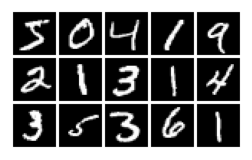

In [12]:
# Visualizamos algunas imágenes reales del subconjunto

n_rows, n_cols = 3, 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

In [13]:
# ============================================================
# Definición del proceso OU con noise schedule lineal
# ============================================================

beta_min = 0.1
beta_max = 20.0

def beta_linear(t, beta_min, beta_max):
    return beta_min + (beta_max - beta_min) * t

def A_linear(t, beta_min, beta_max):
    return beta_min * t + 0.5 * (beta_max - beta_min) * t**2

def alpha_linear(t, beta_min, beta_max):
    return torch.exp(-0.5 * A_linear(t, beta_min, beta_max))

def ou_drift_coefficient(x_t, t, beta_fn):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t

def ou_diffusion_coefficient(t, beta_fn):
    return torch.sqrt(beta_fn(t))

def ou_mu_t(x_0, t, alpha_fn):
    alpha_t = alpha_fn(t).view(-1, 1, 1, 1)
    return alpha_t * x_0

def ou_sigma_t(t, alpha_fn):
    alpha_t = alpha_fn(t)
    return torch.sqrt(1.0 - alpha_t**2)

In [14]:
# Construimos las funciones parciales del proceso

beta_fn = partial(beta_linear, beta_min=beta_min, beta_max=beta_max)
alpha_fn = partial(alpha_linear, beta_min=beta_min, beta_max=beta_max)

drift_coefficient = partial(ou_drift_coefficient, beta_fn=beta_fn)
diffusion_coefficient = partial(ou_diffusion_coefficient, beta_fn=beta_fn)
mu_t = partial(ou_mu_t, alpha_fn=alpha_fn)
sigma_t = partial(ou_sigma_t, alpha_fn=alpha_fn)

diffusion_process = GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [15]:
# Comprobación matemática del proceso VP

t_test = torch.tensor([0.0, 0.25, 0.5, 0.75, 1.0])

print("beta(t):", beta_fn(t_test))
print("alpha(t):", alpha_fn(t_test))
print("sigma_t:", sigma_t(t_test))
print("alpha(t)^2 + sigma_t(t)^2:", alpha_fn(t_test)**2 + sigma_t(t_test)**2)

beta(t): tensor([ 0.1000,  5.0750, 10.0500, 15.0250, 20.0000])
alpha(t): tensor([1.0000, 0.7237, 0.2812, 0.0587, 0.0066])
sigma_t: tensor([0.0000, 0.6902, 0.9597, 0.9983, 1.0000])
alpha(t)^2 + sigma_t(t)^2: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [16]:
# ============================================================
# Definición del modelo ScoreNet
# ============================================================

score_model = ScoreNet(
    marginal_prob_std=sigma_t
).to(device)

print(type(score_model))

<class 'score_model.ScoreNet'>


In [17]:
# Comprobación rápida de la loss antes de entrenar

x_batch, y_batch = next(iter(DataLoader(data_train, batch_size=8, shuffle=True)))
x_batch = x_batch.to(device)

loss_test = diffusion_process.loss_function(score_model, x_batch)
print("Initial test loss:", loss_test.item())

Initial test loss: 6531.771484375


In [20]:
# ============================================================
# Entrenamiento ligero
# ============================================================

from torch.optim import Adam
from tqdm import trange

batch_size = 64

data_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

learning_rate = 1e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

# Pocas épocas porque esto es solo una prueba de caso de uso
n_epochs = 30
loss_history = []

tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    score_model.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history.append(epoch_loss)

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:.5f}")

# Guardamos checkpoint de prueba
torch.save(score_model.state_dict(), "check_point_use_case_ou_linear.pth")

print("Entrenamiento finalizado.")
print("Checkpoint guardado como: check_point_use_case_ou_linear.pth")

Average Loss: 21.28886: 100%|██████████| 30/30 [16:41<00:00, 33.38s/it]

Entrenamiento finalizado.
Checkpoint guardado como: check_point_use_case_ou_linear.pth


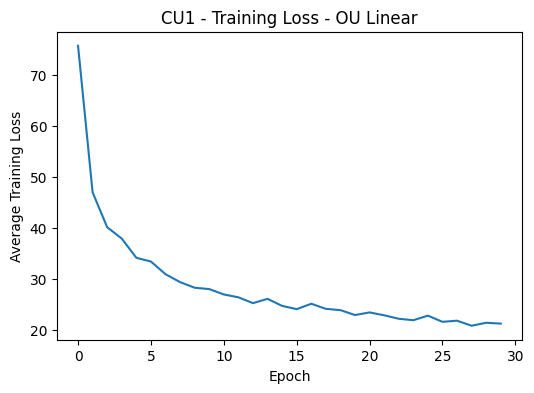

In [21]:
# Curva de pérdida del entrenamiento de prueba

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("CU1 - Training Loss - OU Linear")
plt.show()


El modelo se ha entrenado correctamente sobre un subconjunto reducido de MNIST. Aunque el número de épocas es bajo y el objetivo no es obtener un modelo de alta calidad, la prueba valida el flujo completo de entrenamiento: carga de datos, definición del proceso de difusión, cálculo de la loss, optimización de ScoreNet y guardado del checkpoint.

## CU2. Generación de imágenes

En este caso de uso se comprueba la generación de imágenes sintéticas mediante un modelo ScoreNet previamente entrenado. Se parte de ruido gaussiano y se simula el proceso inverso de difusión usando el integrador de Euler--Maruyama. El modelo estima el score en cada instante temporal y guía la evolución de las muestras hacia imágenes con estructura similar a dígitos manuscritos.

In [22]:
# ============================================================
# CU2. Generación de imágenes con Euler-Maruyama
# ============================================================

# Cargamos el checkpoint entrenado en CU1
score_model.load_state_dict(
    torch.load("check_point_use_case_ou_linear.pth", map_location=device)
)
score_model.eval()

print("Checkpoint cargado correctamente.")

Checkpoint cargado correctamente.


In [23]:
# Drift del proceso inverso OU
# dx = [-1/2 beta(t) x_t - beta(t) s_theta(x_t,t)] dt + sqrt(beta(t)) dW

def backward_drift_coefficient(x_t, t, beta_fn, score_model):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t - beta_t * score_model(x_t, t)

In [24]:
# Parámetros de generación

n_images = 9
T = 1.0
eps = 1.0e-3
n_steps = 500

# Condición inicial del proceso inverso: x_T ~ N(0, I)
torch.manual_seed(42)
x_T = torch.randn(n_images, 1, 28, 28, device=device)

with torch.no_grad():
    times, synthetic_images_t = euler_maruyama_integrator(
        x_0=x_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_coefficient,
            beta_fn=beta_fn,
            score_model=score_model,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

print("Shape de las trayectorias generadas:", synthetic_images_t.shape)

Shape de las trayectorias generadas: torch.Size([9, 1, 28, 28, 501])


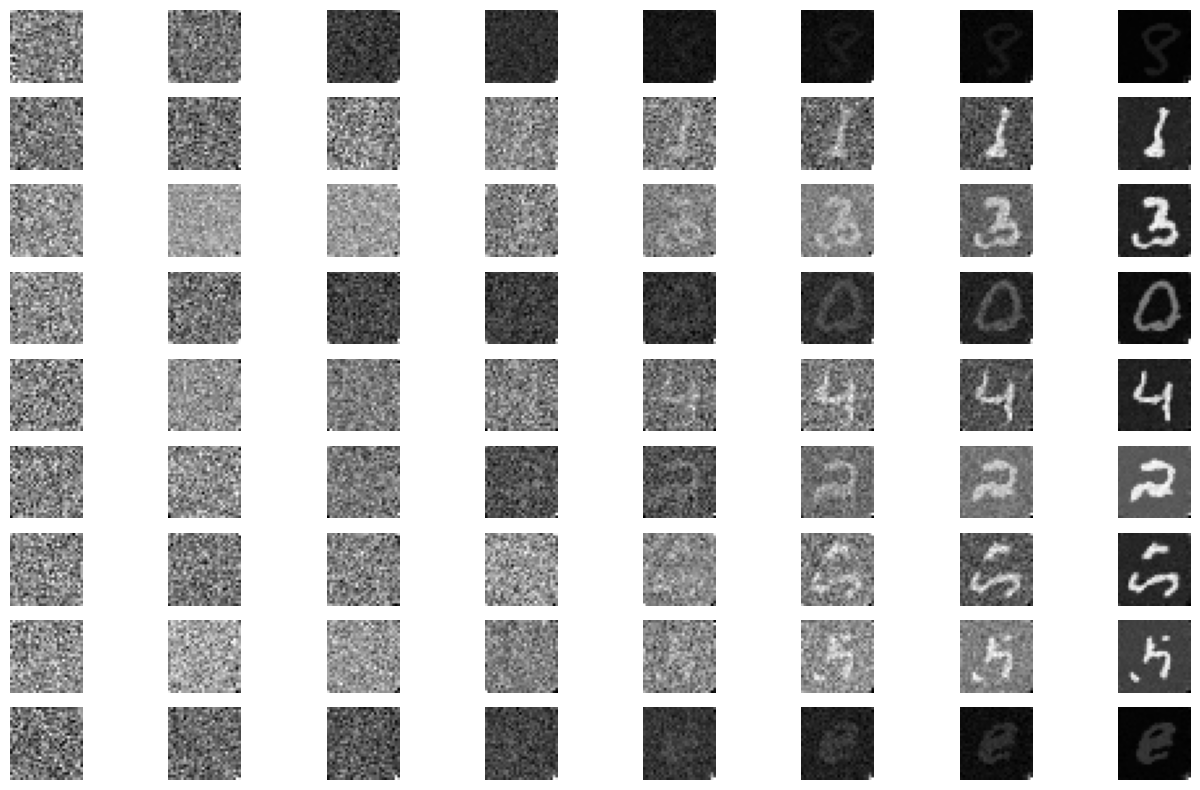

In [25]:
# Visualización de la evolución temporal ruido -> imagen

_ = plot_image_evolution(
    images=synthetic_images_t.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 480, 500],
    figsize=(16, 10),
)

El caso de uso valida que el modelo entrenado puede reutilizarse para generar nuevas muestras. La trayectoria muestra la transición desde ruido gaussiano inicial hasta imágenes estructuradas, siguiendo el proceso inverso de difusión aproximado mediante Euler--Maruyama.

## CU3. Evaluación del modelo

En este caso de uso se evalúa cuantitativamente el modelo entrenado mediante una estimación aproximada de la log-verosimilitud usando la probability flow ODE. Posteriormente, la log-verosimilitud se transforma a bits per dimension (BPD), métrica habitual para comparar modelos generativos.

In [27]:
# ============================================================
# CU3. Evaluación del modelo mediante BPD
# ============================================================

def gaussian_logpdf_general(x, std):
    """
    Log-density of a centered isotropic Gaussian N(0, std^2 I).
    """
    dim = x[0].numel()
    x_flat = x.view(x.shape[0], -1)
    var = std.view(-1) ** 2

    return -0.5 * (
        dim * torch.log(torch.tensor(2 * np.pi, device=x.device))
        + dim * torch.log(var)
        + torch.sum(x_flat ** 2, dim=1) / var
    )


def divergence_hutchinson_general(fn, x, t):
    """
    Hutchinson estimator of the divergence.
    """
    eps_noise = torch.randn_like(x)
    x.requires_grad_(True)

    y = fn(x, t)
    inner = torch.sum(y * eps_noise)

    grad = torch.autograd.grad(inner, x, create_graph=False)[0]
    div = torch.sum(grad * eps_noise, dim=(1, 2, 3))

    return div

In [28]:
def make_probability_flow_drift(drift_coefficient, diffusion_coefficient, score_model):
    """
    Drift of the probability flow ODE:
    f_tilde(x,t) = f(x,t) - 0.5 * g(t)^2 * score(x,t)
    """
    def probability_flow_drift(x_t, t):
        g_t = diffusion_coefficient(t).view(-1, 1, 1, 1)
        return drift_coefficient(x_t, t) - 0.5 * (g_t ** 2) * score_model(x_t, t)

    return probability_flow_drift


def compute_log_likelihood_general(
    x_data,
    score_model,
    drift_coefficient,
    diffusion_coefficient,
    sigma_t,
    T=1.0,
    eps=1e-3,
    n_steps=100,
):
    """
    Approximate log p_0(x) using the probability flow ODE.
    """
    score_model.eval()
    device = x_data.device
    batch_size = x_data.shape[0]

    probability_flow_drift = make_probability_flow_drift(
        drift_coefficient=drift_coefficient,
        diffusion_coefficient=diffusion_coefficient,
        score_model=score_model,
    )

    times = torch.linspace(eps, T, n_steps + 1, device=device)
    dt = times[1] - times[0]

    x = x_data.clone()
    delta_logp = torch.zeros(batch_size, device=device)

    for t_scalar in times[:-1]:
        t_batch = torch.ones(batch_size, device=device) * t_scalar

        x = x.detach().requires_grad_(True)
        drift = probability_flow_drift(x, t_batch)

        div = divergence_hutchinson_general(
            probability_flow_drift,
            x,
            t_batch
        )

        x = (x + drift * dt).detach()
        delta_logp = delta_logp - div.detach() * dt

    sigma_T = sigma_t(torch.ones(batch_size, device=device) * T).view(-1, 1, 1, 1)
    log_pT = gaussian_logpdf_general(x, sigma_T)

    log_p0 = log_pT + delta_logp
    return log_p0


def loglik_to_bpd(log_likelihood, x):
    """
    Convert log-likelihood to bits per dimension.
    """
    num_dims = x[0].numel()
    return -log_likelihood / (num_dims * np.log(2))

In [29]:
# Cargamos el checkpoint del CU1

score_model.load_state_dict(
    torch.load("check_point_use_case_ou_linear.pth", map_location=device)
)
score_model.eval()

print("Modelo cargado para evaluación.")

Modelo cargado para evaluación.


In [32]:
# Dataset de evaluación reducido para que sea rápido

test_subset_size = 500

data_test_full = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

data_test = Subset(data_test_full, range(test_subset_size))

test_loader = DataLoader(
    data_test,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

print("Número de muestras de evaluación:", len(data_test))

Número de muestras de evaluación: 500


In [33]:
# Evaluación BPD aproximada

all_loglik = []
all_bpd = []

max_batches = 2

for i, (x_batch, _) in enumerate(test_loader):
    if i >= max_batches:
        break

    x_batch = x_batch.to(device)

    log_likelihoods = compute_log_likelihood_general(
        x_data=x_batch,
        score_model=score_model,
        drift_coefficient=drift_coefficient,
        diffusion_coefficient=diffusion_coefficient,
        sigma_t=sigma_t,
        T=1.0,
        eps=1e-3,
        n_steps=50,
    )

    bpd_values = loglik_to_bpd(log_likelihoods, x_batch)

    all_loglik.append(log_likelihoods.detach().cpu())
    all_bpd.append(bpd_values.detach().cpu())

all_loglik = torch.cat(all_loglik)
all_bpd = torch.cat(all_bpd)

print("Log-likelihood media:", all_loglik.mean().item())
print("BPD medio:", all_bpd.mean().item())

Log-likelihood media: -5063.6416015625
BPD medio: 9.317973136901855


El caso de uso valida el flujo de evaluación del modelo. Se obtiene una estimación aproximada de la log-verosimilitud y se convierte a BPD. Esta prueba no pretende obtener una métrica definitiva, ya que se emplea un subconjunto reducido y pocas iteraciones de integración, pero confirma que el sistema permite evaluar cuantitativamente modelos de difusión.